#### Setup
Run from `scripts/` so `eval` imports and the `results/` / `output/` paths resolve.

In [ ]:
# These notebooks live in scripts/plotting/, but `eval` and the results/ and output/
# folders are under scripts/. Switch there once so imports and relative paths resolve
# exactly as they do for the harness. Safe to re-run.
import os
import sys

if os.path.basename(os.getcwd()) == "plotting":
    os.chdir("..")
if os.getcwd() not in sys.path:
    sys.path.insert(0, os.getcwd())
print("working directory:", os.getcwd())

### Reloading training data

In [1]:
%%time
import os
import json
import numpy as np

from eval.paths import DATA_ROOT

SAVE_DIR = DATA_ROOT
targets = np.load(os.path.join(SAVE_DIR, "targets_and_masks.npz"))

Xmatch = np.load(os.path.join(SAVE_DIR, "Xmatch.npy"), mmap_mode="r")
Xsub = np.load(os.path.join(SAVE_DIR, "Xsub.npy"), mmap_mode="r")

failed = np.load(os.path.join(SAVE_DIR, "failed.npy"), mmap_mode="r")
hw = np.load(os.path.join(SAVE_DIR, "hw.npy"), mmap_mode="r")
# Current copies, written with the targets by data-processing.ipynb. tr_mask / te_mask
# are before / after 2025-07-01 by E2 label time -- not the experiment split, which
# comes from eval/splits.py.
wait_sv = targets["wait_sv"]
tr_mask = targets["tr_mask"]
te_mask = targets["te_mask"]

with open(os.path.join(SAVE_DIR, "schema_meta.json"), "r") as f:
    meta = json.load(f)

XMATCH_COLS = meta["XMATCH_COLS"]
XSUB_COLS = meta["XSUB_COLS"]
cards = meta["cards"]
NCAT_MATCH = meta["NCAT_MATCH"]
NCAT_SUB = meta["NCAT_SUB"]
n_base = meta["n_base"]

X = Xmatch[:, :n_base]

print(f"Loaded Xmatch {Xmatch.shape} and Xsub {Xsub.shape}")
print(f"Train split: {tr_mask.sum():,} rows | Test split: {te_mask.sum():,} rows")

Loaded Xmatch (64088358, 42) and Xsub (64088358, 26)
Train split: 48,551,819 rows | Test split: 15,536,539 rows
CPU times: user 7.91 s, sys: 59.1 ms, total: 7.97 s
Wall time: 284 ms


Feature inventory

In [2]:
print(f"Xmatch {Xmatch.shape} -- match-time tasks (Failed, hw_fault, 3-class fault):")
for i, nme in enumerate(XMATCH_COLS):
    print(f"  [{i:2d}] {nme}")
print(f"\nXsub {Xsub.shape} -- submission-time task (wait_time):")
for i, nme in enumerate(XSUB_COLS):
    print(f"  [{i:2d}] {nme}")
print("\nstate variables: trail1h_* (leak-free trailing rates, 1h window, self-excluded),")
print("  log_idle_queue_depth (submitted-not-started at submit), log_camp_trail_wait,")
print("  log_*_running (leak-free concurrent-running counts, self-excluded)")
print("targets: Failed (binary) | hw_fault (binary; matched & typed rows) | "
      "fault_type (3-class) | wait_log = log1p(wait s)")

Xmatch (64088358, 42) -- match-time tasks (Failed, hw_fault, 3-class fault):
  [ 0] Group
  [ 1] Owner
  [ 2] PomsLauncher
  [ 3] CampaignName
  [ 4] CampaignStageName
  [ 5] CampaignType
  [ 6] TestLaunch
  [ 7] JobsubGroup
  [ 8] Image
  [ 9] BlacklistSites
  [10] MatchSite
  [11] MatchEntry
  [12] MatchQueue
  [13] MatchResource
  [14] MatchCpus
  [15] RequestCpus (std)
  [16] RequestDisk (std)
  [17] RequestMemory (std)
  [18] RequestSlots (std)
  [19] ExecutableSize (std)
  [20] TransferInputMB (std)
  [21] ExpectedLifetime (std)
  [22] TotalSubmitProcs (std)
  [23] CpusProvisioned (std)
  [24] DiskProvisioned (std)
  [25] MemoryProvisioned (std)
  [26] sin_hour@match
  [27] cos_hour@match
  [28] sin_wday@match
  [29] cos_wday@match
  [30] trail1m_site_fail
  [31] trail60m_site_fail
  [32] trail1m_site_hw
  [33] trail60m_site_hw
  [34] trail1m_camp_fail
  [35] trail60m_camp_fail
  [36] trail60m_node_fail
  [37] trail1440m_node_fail
  [38] trail60m_node_hw
  [39] trail1440m_node_hw

#### Experiment setup

In [3]:
# E1: split-protocol decomposition (Delta): random vs temporal on the same features
import psutil

def mem_gb():
    return psutil.Process().memory_info().rss / (1024 ** 3)

# Target vector & population indices
yv = failed
idx = np.arange(len(yv))

# 1. Temporal split indices (Feb-Jun Train vs Jul-Aug Test)
tri_t = np.where(tr_mask)[0]
tei_t = np.where(te_mask)[0]

# 2. Random split indices (same test size, randomly sampled across all data)
rng = np.random.default_rng(0)
perm = rng.permutation(idx)
rte = np.sort(perm[:len(tei_t)])
rtr = np.sort(perm[len(tei_t):])

E1_SPLITS = [("random", rtr, rte), ("temporal", tri_t, tei_t)]

# Storage dicts (accumulate results across individual model cells)
E1_IMP, E1_CM = {}, {}

print(f"E1 splits prepared: Random ({len(rtr):,} train / {len(rte):,} test) | Temporal ({len(tri_t):,} train / {len(tei_t):,} test)")

E1 splits prepared: Random (48,551,819 train / 15,536,539 test) | Temporal (48,551,819 train / 15,536,539 test)


### Failure prediction: XGBoost
Can also be run in the terminal, example: `python -m eval.harness e1 xgboost`

In [ ]:
import importlib
import train.tree
importlib.reload(train.tree)
import eval.harness
importlib.reload(eval.harness)
from eval.harness import run_e1_model

print("--- Running E1: XGBoost ---")
print("-" * 55)

run_e1_model("xgboost", Xmatch, yv, E1_SPLITS, E1_IMP, E1_CM, NCAT_MATCH)

print("-" * 55)
print(f"[mem] Peak RSS: {mem_gb():.2f} GB", flush=True)

## E1 Results

In [14]:
%%time
import warnings
import importlib
import eval.helper
importlib.reload(eval.helper)
from eval.helper import load_saved_importances
from eval.paths import model_dir

# Prepare evaluation slice
eval_idx = tei_t[:200000]
X_eval = np.ascontiguousarray(Xmatch[eval_idx], dtype=np.float32)
y_eval = np.ascontiguousarray(yv[eval_idx])

with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    # Models live in <MODEL_ROOT>/e1/<model>/ with no experiment tag in the filename,
    # so point the loader at those directories rather than matching on a tag.
    _models = ["xgboost", "lightgbm", "catboost", "mlp", "tabnet", "saint", "ft", "tsmixer"]
    E1_IMP = load_saved_importances(
        models=_models,
        model_dirs=[model_dir("e1", m, create=False) for m in _models],
        exp_tag=None,
        splits=["random", "temporal"],
        n_feats=len(XMATCH_COLS),
        X_eval=X_eval,
        y_eval=y_eval
    )

[Loaded Tree Model] xgboost    (random  ) <- /mnt/scratch/ssd/amaustin/models/e1/xgboost/xgboost_bin_random.json
[Loaded Tree Model] xgboost    (temporal) <- /mnt/scratch/ssd/amaustin/models/e1/xgboost/xgboost_bin_temporal.json
[Loaded Tree Model] lightgbm   (random  ) <- /mnt/scratch/ssd/amaustin/models/e1/lightgbm/lightgbm_bin_random.txt
[Loaded Tree Model] lightgbm   (temporal) <- /mnt/scratch/ssd/amaustin/models/e1/lightgbm/lightgbm_bin_temporal.txt
[Loaded Tree Model] catboost   (random  ) <- /mnt/scratch/ssd/amaustin/models/e1/catboost/catboost_bin_random.txt
[Loaded Tree Model] catboost   (temporal) <- /mnt/scratch/ssd/amaustin/models/e1/catboost/catboost_bin_temporal.txt
[Computed Permutation Imp] mlp        (random  ) on cuda
[Computed Permutation Imp] mlp        (temporal) on cuda
CPU times: user 18.1 s, sys: 1.17 s, total: 19.3 s
Wall time: 8.84 s


KeyboardInterrupt: 

#### Feature importance - random split

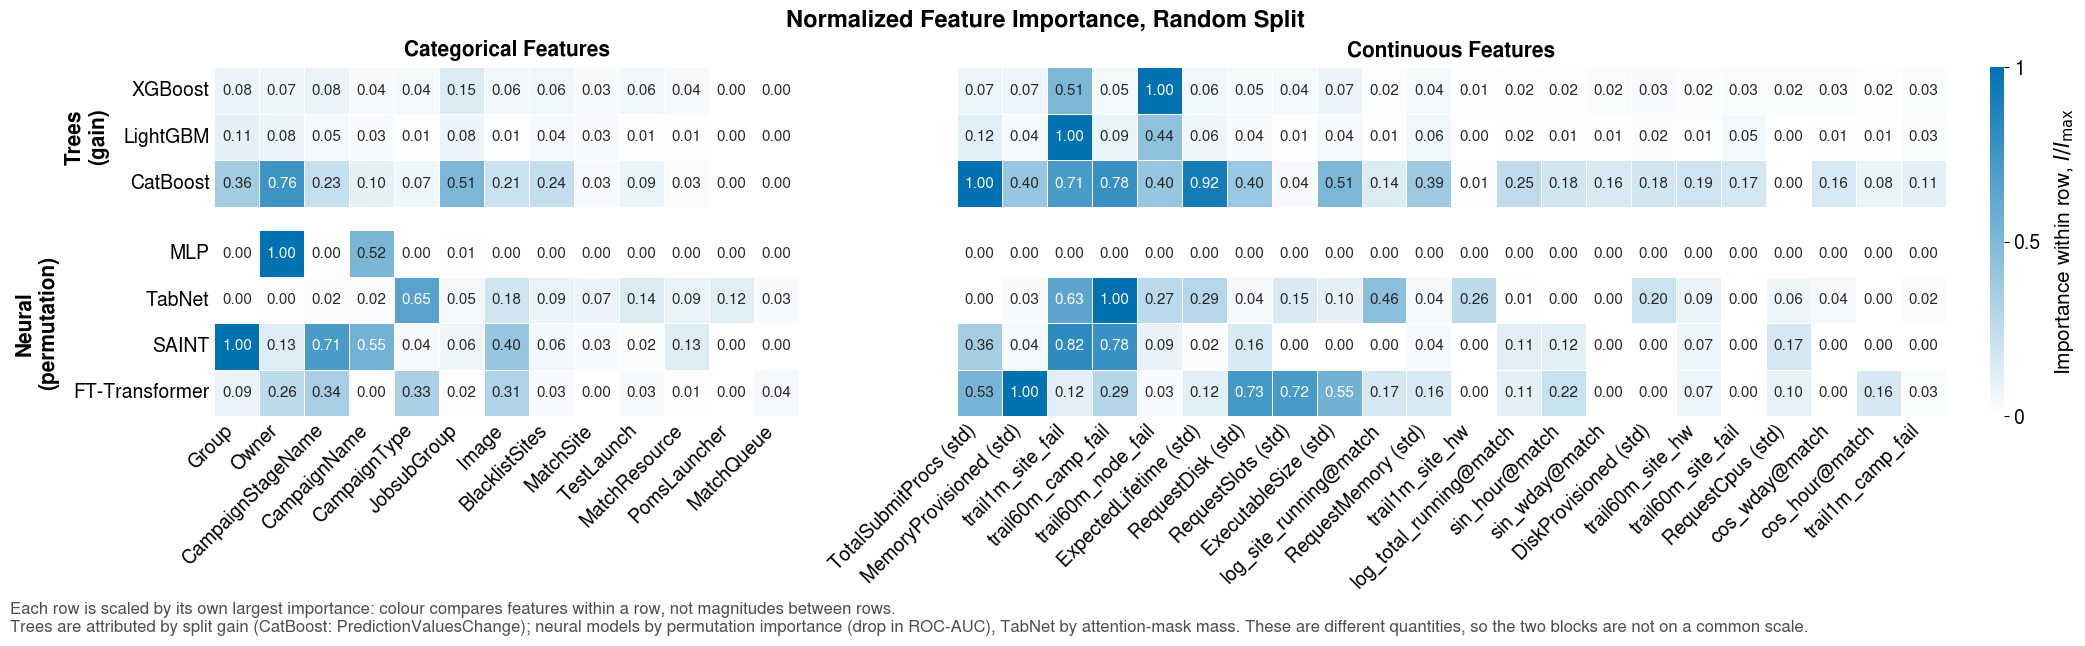

In [19]:
import importlib
import eval.helper

importlib.reload(eval.helper)
from eval.helper import feature_split_imp_heatmap

df_cat, df_non_cat = feature_split_imp_heatmap(
    imp_dict=E1_IMP,
    feats=XMATCH_COLS,
    n_cat=NCAT_MATCH,  
    split_key="random",
    output_prefix="feature_split_imp_heatmap",
)

#### Feature importance - temporal split

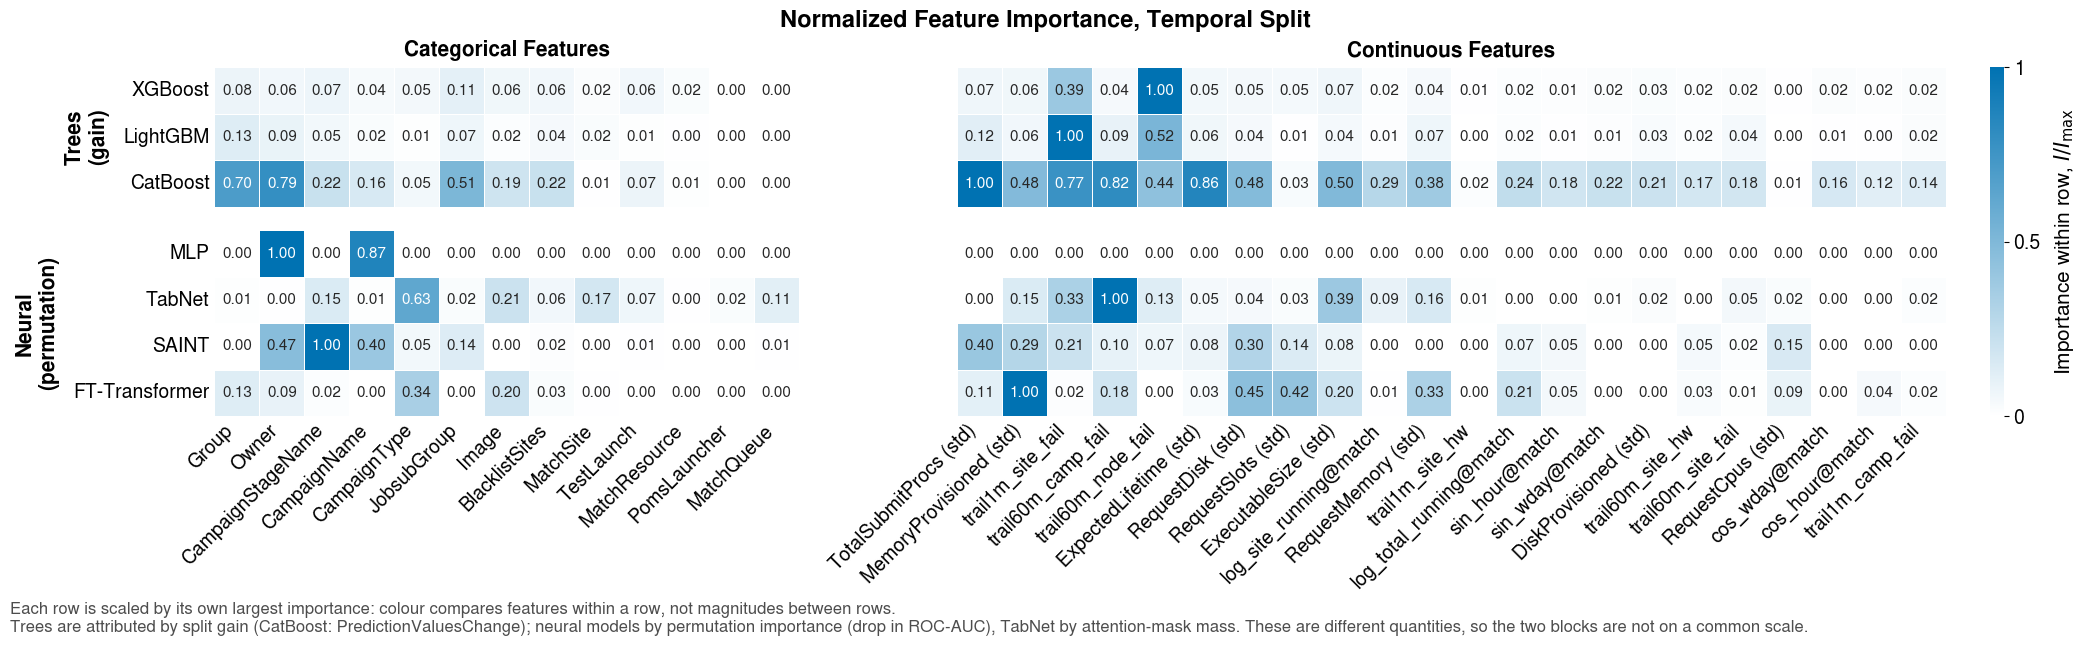

In [20]:
import importlib
import eval.helper

importlib.reload(eval.helper)
from eval.helper import feature_split_imp_heatmap

df_cat, df_non_cat = feature_split_imp_heatmap(
    imp_dict=E1_IMP,
    feats=XMATCH_COLS,
    n_cat=NCAT_MATCH,  
    split_key="temporal",
    output_prefix="feature_split_imp_heatmap",
)

### Feature gain shift (random split -> temporal)

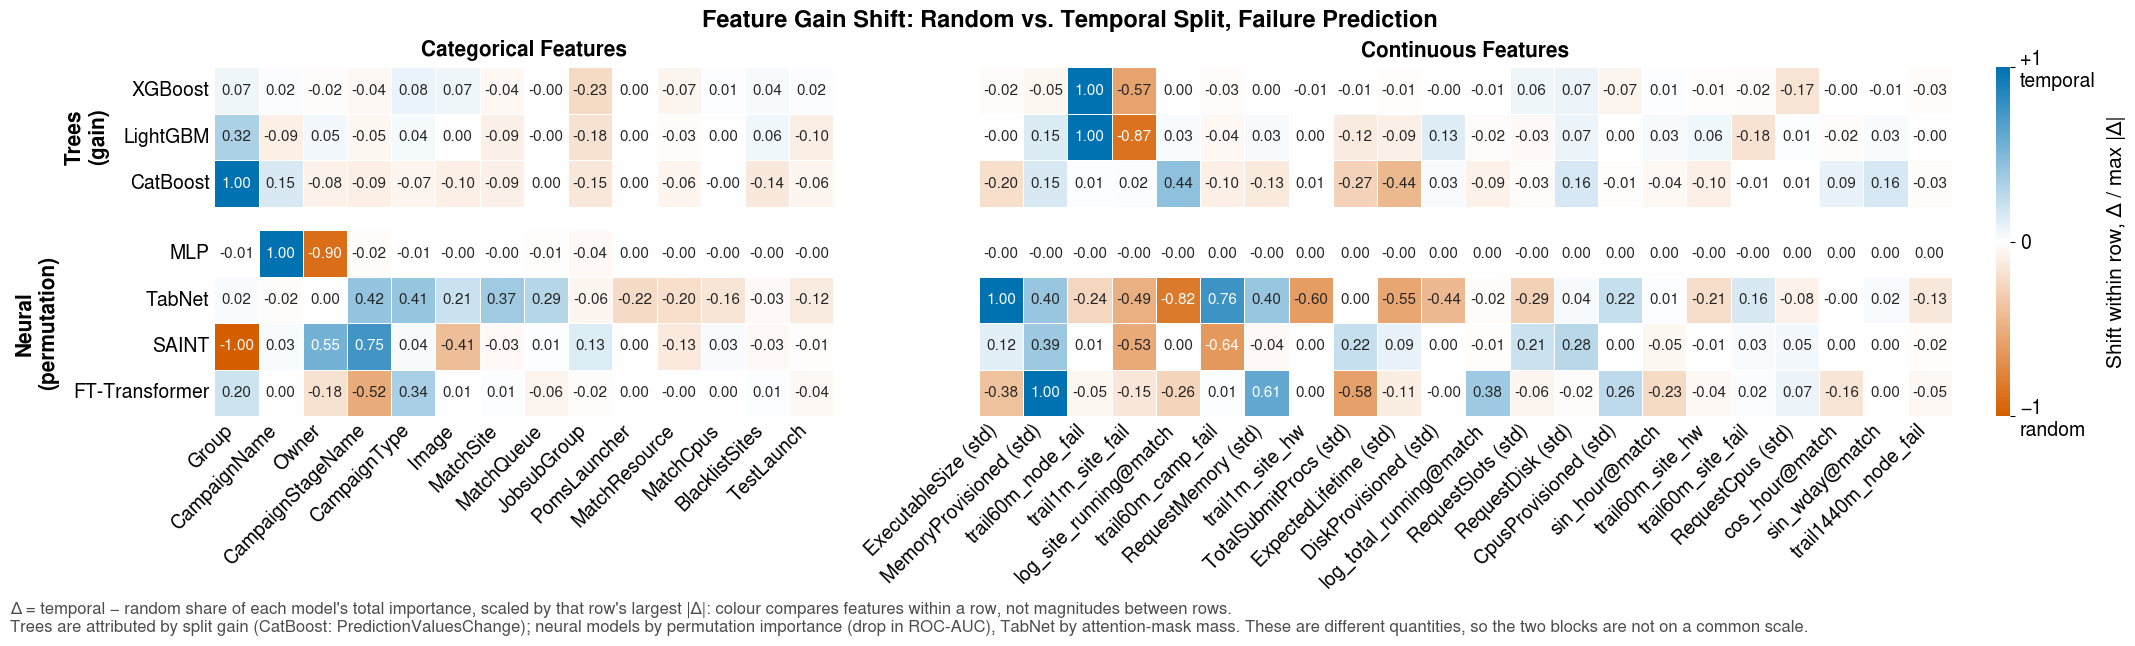

,Group,CampaignName,Owner,CampaignStageName,CampaignType,Image,MatchSite,MatchQueue,JobsubGroup,PomsLauncher,...,RequestSlots (std),RequestDisk (std),CpusProvisioned (std),sin_hour@match,trail60m_site_hw,trail60m_site_fail,RequestCpus (std),cos_hour@match,sin_wday@match,trail1440m_node_fail
XGBoost,0.065171,0.017077,-0.016179,-0.042587,0.081479,0.065203,-0.044446,-0.000519,-0.228606,0.000000,...,0.063876,0.072122,-0.070188,0.011539,-0.012773,-0.021050,-1.706405e-01,-0.003765,-0.005402,-0.030904
LightGBM,0.321520,-0.094413,0.054636,-0.049680,0.042974,0.004076,-0.090787,-0.000950,-0.180638,0.000000,...,-0.034499,0.072607,0.000000,0.032363,0.059387,-0.175788,1.147411e-02,-0.019358,0.030102,-0.001560
CatBoost,1.000000,0.154517,-0.079951,-0.094577,-0.068028,-0.095637,-0.090323,0.000949,-0.146421,0.000000,...,-0.026820,0.160195,-0.009542,-0.041544,-0.098762,-0.005203,6.144390e-03,0.092186,0.156537,-0.025305
MLP,-0.005809,1.000000,-0.898748,-0.021852,-0.005272,-0.000190,-0.003721,-0.009293,-0.037992,0.000000,...,-0.000082,0.000000,0.000022,0.000003,-0.000130,-0.000005,6.092222e-07,0.000000,0.000000,0.000007
TabNet,0.024424,-0.023332,0.004821,0.420961,0.407567,0.209515,0.372796,0.286548,-0.056172,-0.222657,...,-0.286031,0.037231,0.218998,0.008136,-0.208558,0.156188,-7.880998e-02,-0.000485,0.024008,-0.134782
SAINT,-1.000000,0.025071,0.545606,0.745963,0.035677,-0.406015,-0.032105,0.008225,0.132925,0.000000,...,0.209622,0.278320,0.000000,-0.051907,-0.007702,0.027535,5.079975e-02,0.000000,0.000000,-0.015276
FT-Transformer,0.198017,0.000299,-0.180088,-0.519502,0.343219,0.007161,0.010954,-0.063491,-0.016317,0.000000,...,-0.062571,-0.019744,0.258290,-0.233009,-0.042242,0.020893,7.096665e-02,-0.163669,0.000000,-0.046478


In [21]:
import importlib
import eval.helper
importlib.reload(eval.helper)
from eval.helper import imp_diff_heatmap

# One table, each row scaled by its own max |delta|. Trees and neural models sit in
# separate row blocks: split gain and permutation importance are different quantities,
# so the per-row scaling does not put them on a common footing (see the figure note).
imp_diff_heatmap(
    imp_dict=E1_IMP,
    feats=XMATCH_COLS,
    n_cat=NCAT_MATCH,
    per_model_scale=False,
    title="Feature Gain Shift: Random vs. Temporal Split, Failure Prediction",
    output_prefix="imp_diff_heatmap",
)


Running evaluation only (on all models)

In [ ]:
import importlib
import eval.helper
importlib.reload(eval.helper)
from eval.helper import evaluate_protocol_models

results = evaluate_protocol_models(
    X_all=Xmatch,
    y_all=yv,
    rtr=rtr,  
    rte=rte, 
    tri_t=tri_t, 
    tei_t=tei_t, 
    output_path="output/protocol_eval_results.json",
)
results

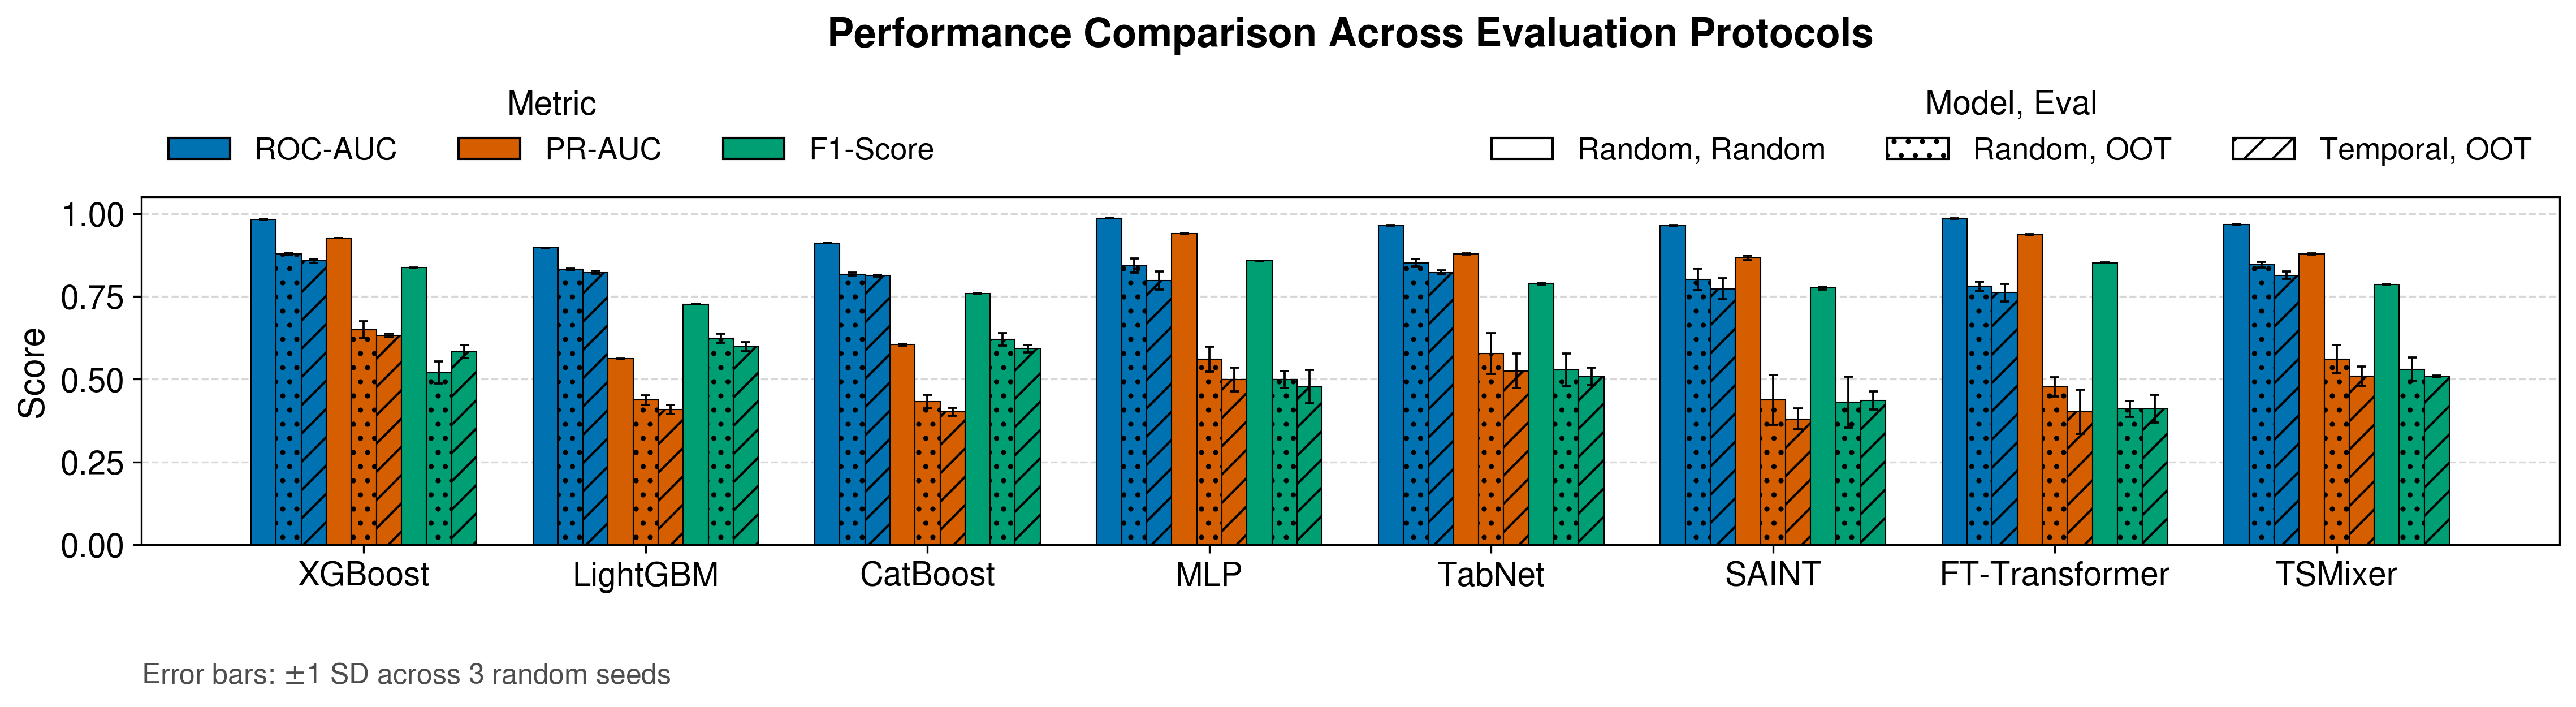

Saved plots to:
  - /home/amaustin/Research/fife-batch-jobs/scripts/output/protocol_ablation_summary.pdf
  - /home/amaustin/Research/fife-batch-jobs/scripts/output/protocol_ablation_summary.png
Seeds aggregated per bar: [3]
  XGBoost         temporal PR-AUC 0.6316 +/- 0.0049  (n=3)
  LightGBM        temporal PR-AUC 0.4088 +/- 0.0139  (n=3)
  CatBoost        temporal PR-AUC 0.4019 +/- 0.0120  (n=3)
  MLP             temporal PR-AUC 0.4989 +/- 0.0358  (n=3)
  TabNet          temporal PR-AUC 0.5253 +/- 0.0515  (n=3)
  SAINT           temporal PR-AUC 0.3800 +/- 0.0317  (n=3)
  FT-Transformer  temporal PR-AUC 0.4015 +/- 0.0673  (n=3)
  TSMixer         temporal PR-AUC 0.5084 +/- 0.0291  (n=3)


In [ ]:
METRICS = [
    ("roc_auc", "ROC-AUC"),
    ("pr_auc",  "PR-AUC"),
    ("f1",      "F1-Score"),
]
# (training split, label, hatch, metric prefix) -- each bar is a (model, test set).
# Both out-of-time arms read the shared OOT slice ("oot."): the August jobs neither arm
# trained on, so the two are scored on identical rows.
PROTOCOLS = [
    ("random",   "Random, Random",   "",   ""),
    ("random",   "Random, OOT",   "..", "oot."),
    ("temporal", "Temporal, OOT", "//", "oot."),
]
# Which seed each bar shows. "mean" averages every seed and draws +/-1 SD; "best"
# picks the single seed that scored highest on PRIMARY and draws ALL of that seed's
# metrics, so the bars describe one model that actually existed rather than a
# per-metric maximum stitched from different runs. Best-seed bars carry no error bar,
# because there is no spread in a single run.
SEED_PICK = "mean"          # "mean" | "best"
PRIMARY = "pr_auc"
# ----------------------------------------------------------------------------------

import json
import os
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import numpy as np
from eval.helper import aggregate_seeds
from eval.style import SERIES

notebook_dir = os.getcwd()
RESULTS = os.path.join(notebook_dir, "results/protocol_eval_results.json")

MODEL_ORDER = {"xgboost":"XGBoost","lightgbm":"LightGBM","catboost":"CatBoost","mlp":"MLP",
               "tabnet":"TabNet","saint":"SAINT","ft":"FT-Transformer","tsmixer":"TSMixer"}

with open(RESULTS) as f: results = json.load(f)
model_keys = [k for k in MODEL_ORDER if k in results]
models = [MODEL_ORDER[k] for k in model_keys]

def _flat_run(d, prefix=""):
    """Flatten nested metric blocks to dotted keys ("oot.hardware.pr_auc")."""
    out = {}
    for k, v in d.items():
        if isinstance(v, dict):
            out.update(_flat_run(v, f"{prefix}{k}."))
        elif isinstance(v, (int, float)) and not isinstance(v, bool):
            out[f"{prefix}{k}"] = float(v)
    return out


def stat(mkey, split, metric):
    """value, spread, n for this model/split. Spread is the SD across seeds in "mean"
    mode and 0 in "best" mode, where a single run is plotted."""
    # Seeded runs only: the plain `<split>` key is an older single run from before the
    # shared OOT slice, scored on a different test set.
    runs = [v for k, v in results[mkey].items() if k.startswith(f"{split}__seed")]
    if not runs:
        return np.nan, 0.0, 0
    if SEED_PICK == "best":
        flat = [_flat_run(r) for r in runs]
        scored = [f for f in flat if PRIMARY in f]
        pick = max(scored, key=lambda f: f[PRIMARY]) if scored else flat[0]
        return pick.get(metric, np.nan), 0.0, len(runs)
    b = aggregate_seeds(runs).get(metric)
    return (b["mean"], b["std"], b["n"]) if b else (np.nan, 0.0, 0)

# One base size drives every text element, so nothing drifts when the figure resizes.
FONT = 14
plt.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": "Nimbus Sans",
    "font.size": FONT,
    "axes.labelsize": FONT + 1,
    "axes.titlesize": FONT + 3,
    "xtick.labelsize": FONT,
    "ytick.labelsize": FONT,
    "legend.fontsize": FONT - 1,
    "legend.title_fontsize": FONT,
})

n_bars = len(METRICS) * len(PROTOCOLS)
# 0.8 of the slot, shared out; at 6 bars this reproduces the previous 0.13.
w = 0.8 / n_bars

fig, ax = plt.subplots(figsize=(max(13, 1.7 * n_bars), 5), dpi=300)
x = np.arange(len(models))
offsets = (np.arange(n_bars) - (n_bars - 1) / 2) * w

seed_counts = set()
i = 0
for _mi, (mkey, mlabel) in enumerate(METRICS):
    color = SERIES[_mi % len(SERIES)]
    for pkey, plabel, hatch, mpref in PROTOCOLS:
        vals, errs = [], []
        for k in model_keys:
            mu, sd, n = stat(k, pkey, mpref + mkey)
            vals.append(mu); errs.append(sd); seed_counts.add(n)
        ax.bar(x + offsets[i], vals, w, color=color, edgecolor="black", linewidth=0.5,
               hatch=hatch,
               # Error bars are +/-1 SD across seeds; absent when a single seed was run.
               yerr=errs if any(e > 0 for e in errs) else None,
               error_kw=dict(ecolor="black", elinewidth=0.9, capsize=2, capthick=0.9),
               zorder=3)
        i += 1

ax.set_ylabel("Score")
ax.set_xticks(x); ax.set_xticklabels(models)
ax.set_ylim(0, 1.05)
ax.grid(axis="y", linestyle="--", alpha=0.5); ax.set_axisbelow(True)
ns = sorted(n for n in seed_counts if n)
ax.set_title("Performance Comparison Across Evaluation Protocols",
             pad=64, fontweight="bold")
# Seed provenance belongs on the figure, but under the axes so it cannot collide
# with the legends stacked above the title.
if ns and max(ns) > 1:
    rng_txt = f"{min(ns)}" + (f"-{max(ns)}" if min(ns) != max(ns) else "")
    note = (f"Bars show the single best seed of {rng_txt} by {PRIMARY}; all metrics "
            f"come from that one run, so there is no spread to draw."
            if SEED_PICK == "best" else
            f"Error bars: $\\pm$1 SD across 3 random seeds")
else:
    note = "Single seed per configuration; no variance estimate available."
ax.annotate(note, xy=(0, -0.34), xycoords="axes fraction", fontsize=FONT - 2,
            ha="left", va="top", color="0.30")

leg1 = ax.legend(handles=[Patch(facecolor=SERIES[i % len(SERIES)], edgecolor="black",
                                label=l) for i, (_, l) in enumerate(METRICS)],
                 title="Metric", loc="lower left", bbox_to_anchor=(0.0, 1.01),
                 ncol=len(METRICS), frameon=False, alignment="center")
ax.add_artist(leg1)
ax.legend(handles=[Patch(facecolor="white", edgecolor="black", hatch=h, label=l)
                   for _, l, h, _p in PROTOCOLS],
          title="Model, Eval", loc="lower right", bbox_to_anchor=(1.0, 1.01),
          ncol=len(PROTOCOLS), frameon=False, alignment="center")

plt.tight_layout()

os.makedirs(os.path.join(notebook_dir, "output"), exist_ok=True)
pdf_path = os.path.join(notebook_dir, "output/protocol_ablation_summary.pdf")
plt.savefig(pdf_path, bbox_inches="tight")
plt.show()

print(f"Saved plots to:\n  - {pdf_path}")
print(f"Seeds aggregated per bar: {sorted(n for n in seed_counts if n)}")
for k in model_keys:
    mu, sd, n = stat(k, "temporal", "pr_auc")
    print(f"  {MODEL_ORDER[k]:15s} temporal PR-AUC {mu:.4f} +/- {sd:.4f}  (n={n})")


### E3: fault attribution (hardware vs payload), conditional on failure

Random, Random    727,835 failed jobs | hardware  5.81%
Random, OOT       745,942 failed jobs | hardware 13.66%
Temporal, OOT     745,942 failed jobs | hardware 13.66%

         model            arm  n hardware.pr_auc roc_auc hardware.f1   mcc
       XGBoost Random, Random  3           0.932   0.995       0.854 0.846
       XGBoost    Random, OOT  3           0.256   0.677       0.111 0.140
       XGBoost  Temporal, OOT  3           0.205   0.620       0.225 0.043
      LightGBM Random, Random  3           0.477   0.954       0.650 0.665
      LightGBM    Random, OOT  3           0.187   0.581       0.277 0.198
      LightGBM  Temporal, OOT  3           0.163   0.557       0.228 0.128
      CatBoost Random, Random  3           0.565   0.969       0.724 0.733
      CatBoost    Random, OOT  3           0.172   0.560       0.231 0.162
      CatBoost  Temporal, OOT  3           0.154   0.542       0.198 0.097
           MLP Random, Random  3           0.904   0.993       0.819 0.809
      

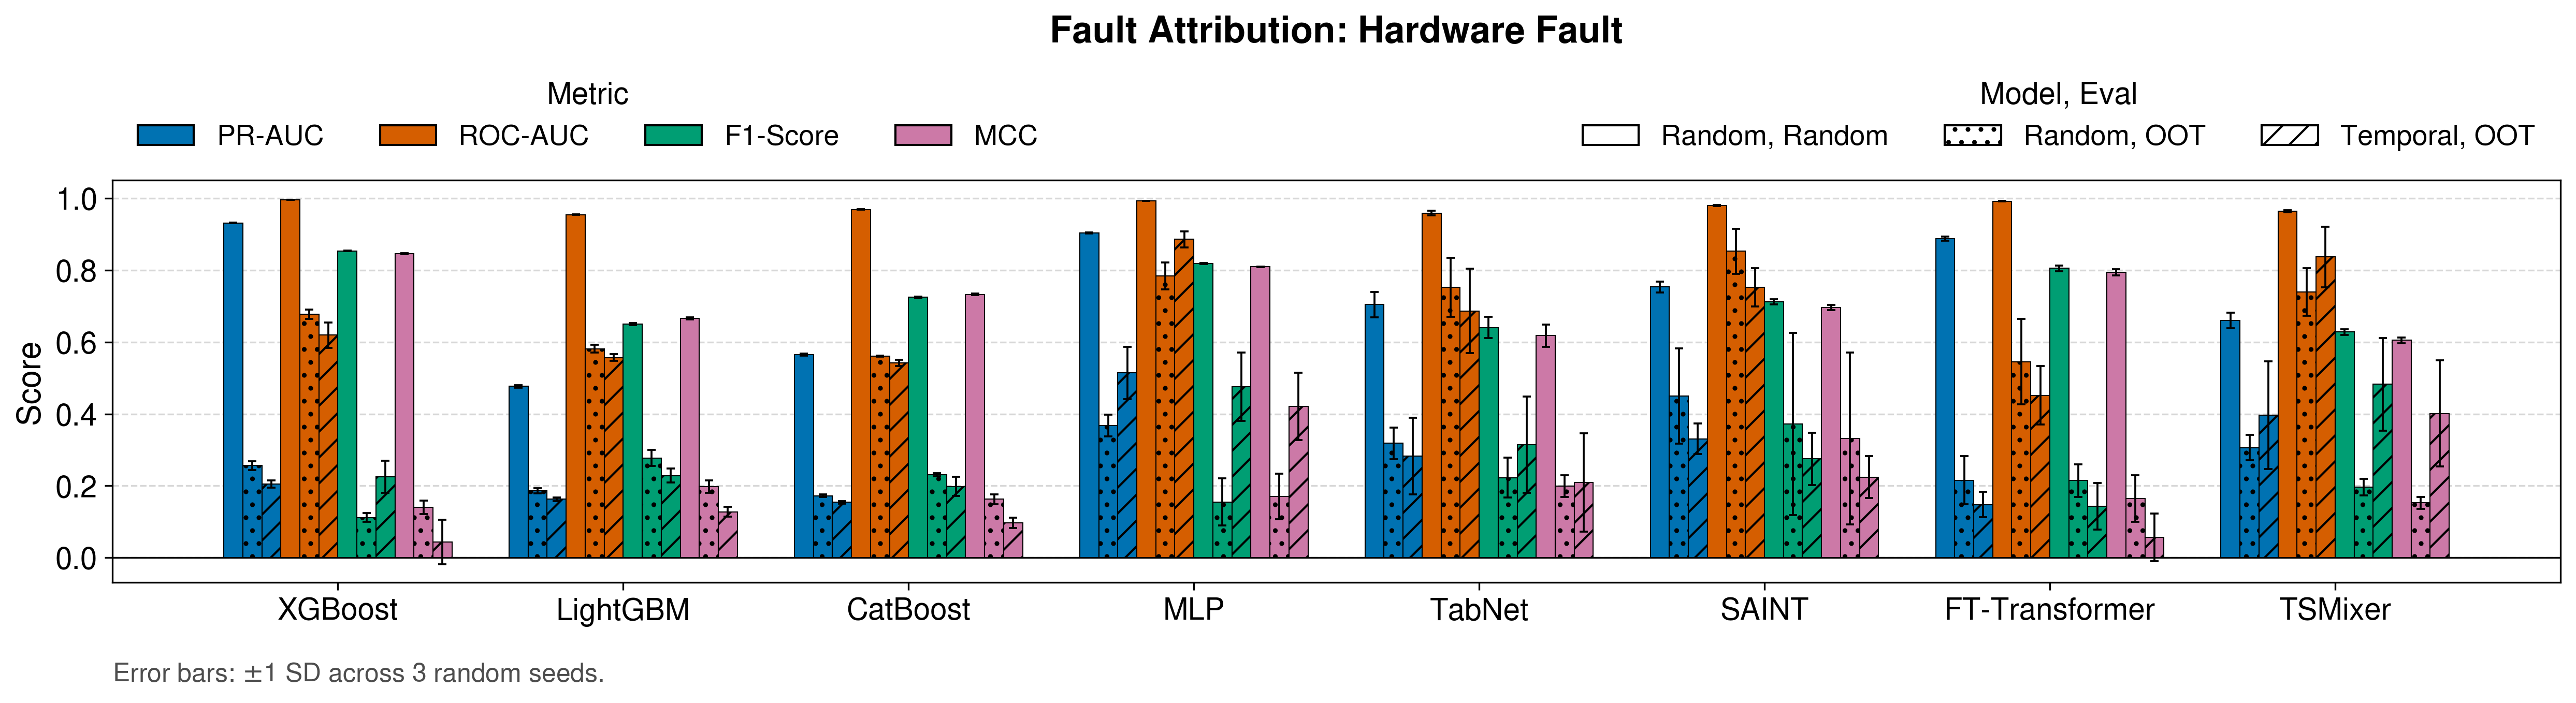

Saved /home/amaustin/Research/fife-batch-jobs/scripts/output/e3_fault_attribution_hardware.pdf / .png


In [ ]:
# E3 hardware chart: hardware is the positive class, scored at its own tuned threshold.
METRICS = [
    ("hardware.pr_auc",    "PR-AUC"),
    ("roc_auc",   "ROC-AUC"),
    # ("hardware.precision", "Precision"),
    # ("hardware.recall",    "Recall"),
    ("hardware.f1",        "F1-Score"),
    ("mcc",                "MCC"),
]
# (training split, label, hatch, metric prefix). Both out-of-time arms read the shared
# OOT slice ("oot."), the August jobs neither arm trained on, so the two are scored on
# identical rows. The temporal split's own test set (July) is what the paper table uses.
PROTOCOLS = [
    ("random",   "Random, Random", "",   ""),
    ("random",   "Random, OOT",    "..", "oot."),
    ("temporal", "Temporal, OOT",  "//", "oot."),
]
CLASSES = [("hardware", "Hardware Fault")]
# ----------------------------------------------------------------------------------

# E3 answers "given that this job failed, which kind of fault was it?" -- every number
# here is CONDITIONAL on failure; the cascade gives the full-population figure.
import json
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

from eval.helper import aggregate_seeds
from eval.style import SERIES

RESULTS = os.path.join(os.getcwd(), "results/fault_attr_results.json")
MODEL_ORDER = {"xgboost": "XGBoost", "lightgbm": "LightGBM", "catboost": "CatBoost",
               "mlp": "MLP", "tabnet": "TabNet", "saint": "SAINT",
               "ft": "FT-Transformer", "tsmixer": "TSMixer"}

with open(RESULTS) as f:
    results = json.load(f)
model_keys = [k for k in MODEL_ORDER if k in results]


def stat(mkey, split, metric):
    """Mean, SD and n over the seeded runs of this model/split. The plain `<split>` key
    is skipped: it is an older single run from before the shared OOT slice, scored on a
    different test set, and averaging it in skews both the bar and its error bar."""
    runs = [v for k, v in results[mkey].items() if k.startswith(f"{split}__seed")]
    b = aggregate_seeds(runs).get(metric) if runs else None
    return (b["mean"], b["std"], b["n"]) if b else (np.nan, 0.0, 0)


# Test-set sizes and class rates per arm, for the notes and the printed table.
_ref = model_keys[0]
ARM_INFO = {}
for pkey, plabel, _h, mpref in PROTOCOLS:
    n, _, _ = stat(_ref, pkey, mpref + "n_test")
    ARM_INFO[plabel] = {"n": n, "hardware": stat(_ref, pkey, f"{mpref}hardware.prevalence")[0]}
for plabel, info in ARM_INFO.items():
    print(f"{plabel:15s} {int(info['n']):>9,} failed jobs | hardware "
          f"{info['hardware'] * 100:5.2f}%")

# ------------------------------------------------------------------ table
rows = []
for mk in model_keys:
    for pkey, plabel, _h, mpref in PROTOCOLS:
        rec = {"model": MODEL_ORDER[mk], "arm": plabel}
        for m, _l in METRICS:
            mu, sd, n = stat(mk, pkey, mpref + m)
            rec[m], rec["n"] = mu, n
        rows.append(rec)
table = pd.DataFrame(rows)
_cols = [m for m, _ in METRICS]
print()
print(table[["model", "arm", "n"] + _cols].to_string(
    index=False, formatters={c: "{:.3f}".format for c in _cols}))

# ------------------------------------------------------------------ figures
FONT = 14
plt.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": "Nimbus Sans",
    "font.size": FONT,
    "axes.labelsize": FONT + 1,
    "axes.titlesize": FONT + 3,
    "xtick.labelsize": FONT,
    "ytick.labelsize": FONT,
    "legend.fontsize": FONT - 1,
    "legend.title_fontsize": FONT,
})
models = [MODEL_ORDER[k] for k in model_keys]
n_bars = len(METRICS) * len(PROTOCOLS)
w = 0.8 / n_bars
offsets = (np.arange(n_bars) - (n_bars - 1) / 2) * w
x = np.arange(len(models))
os.makedirs(os.path.join(os.getcwd(), "output"), exist_ok=True)

for cls, clabel in CLASSES:
    fig, ax = plt.subplots(figsize=(max(13, 1.4 * n_bars), 5), dpi=300)
    seed_counts, i, _lo = set(), 0, 0.0
    for _mi, (mkey, _l) in enumerate(METRICS):
        for pkey, _pl, hatch, mpref in PROTOCOLS:
            vals, errs = [], []
            for k in model_keys:
                mu, sd, n = stat(k, pkey, mpref + mkey)
                vals.append(mu); errs.append(sd); seed_counts.add(n)
                _lo = min(_lo, mu - sd) if np.isfinite(mu) else _lo
            ax.bar(x + offsets[i], vals, w, color=SERIES[_mi % len(SERIES)],
                   edgecolor="black", linewidth=0.5, hatch=hatch,
                   # +/-1 SD across seeds; absent when every seed reproduced exactly.
                   yerr=errs if any(e > 0 for e in errs) else None,
                   error_kw=dict(ecolor="black", elinewidth=0.9, capsize=2, capthick=0.9),
                   zorder=3)
            i += 1

    ax.set_ylabel("Score")
    ax.set_xticks(x); ax.set_xticklabels(models)
    # MCC can be negative; drop the floor below zero only when a bar needs it.
    ax.set_ylim(min(0.0, _lo - 0.05), 1.05)
    if _lo < 0:
        ax.axhline(0, color="black", linewidth=0.8, zorder=2)
    ax.grid(axis="y", linestyle="--", alpha=0.5); ax.set_axisbelow(True)
    ax.set_title(f"Fault Attribution: {clabel}", pad=64,
                 fontweight="bold")

    ns = sorted(n for n in seed_counts if n)
    rng_txt = f"{min(ns)}" + (f"-{max(ns)}" if min(ns) != max(ns) else "")
    note = (f"Error bars: $\\pm$1 SD across {rng_txt} random seeds.")
    ax.annotate(note, xy=(0, -0.2), xycoords="axes fraction", fontsize=FONT - 2,
                ha="left", va="top", color="0.30")

    leg1 = ax.legend(handles=[Patch(facecolor=SERIES[j % len(SERIES)], edgecolor="black",
                                    label=l) for j, (_, l) in enumerate(METRICS)],
                     title="Metric", loc="lower left", bbox_to_anchor=(0.0, 1.01),
                     ncol=len(METRICS), frameon=False, alignment="center")
    ax.add_artist(leg1)
    ax.legend(handles=[Patch(facecolor="white", edgecolor="black", hatch=h, label=l)
                       for _, l, h, _p in PROTOCOLS],
              title="Model, Eval", loc="lower right", bbox_to_anchor=(1.0, 1.01),
              ncol=len(PROTOCOLS), frameon=False, alignment="center")

    plt.tight_layout()
    stem = os.path.join(os.getcwd(), f"output/e3_fault_attribution_{cls}")
    plt.savefig(stem + ".pdf", bbox_inches="tight")
    plt.show()
    print(f"Saved {stem}.pdf")


#### E3: Temporal vs Random on the August slice -- seed consistency

Reads `results/oot_significance.csv` (`eval.helper.oot_protocol_significance`).

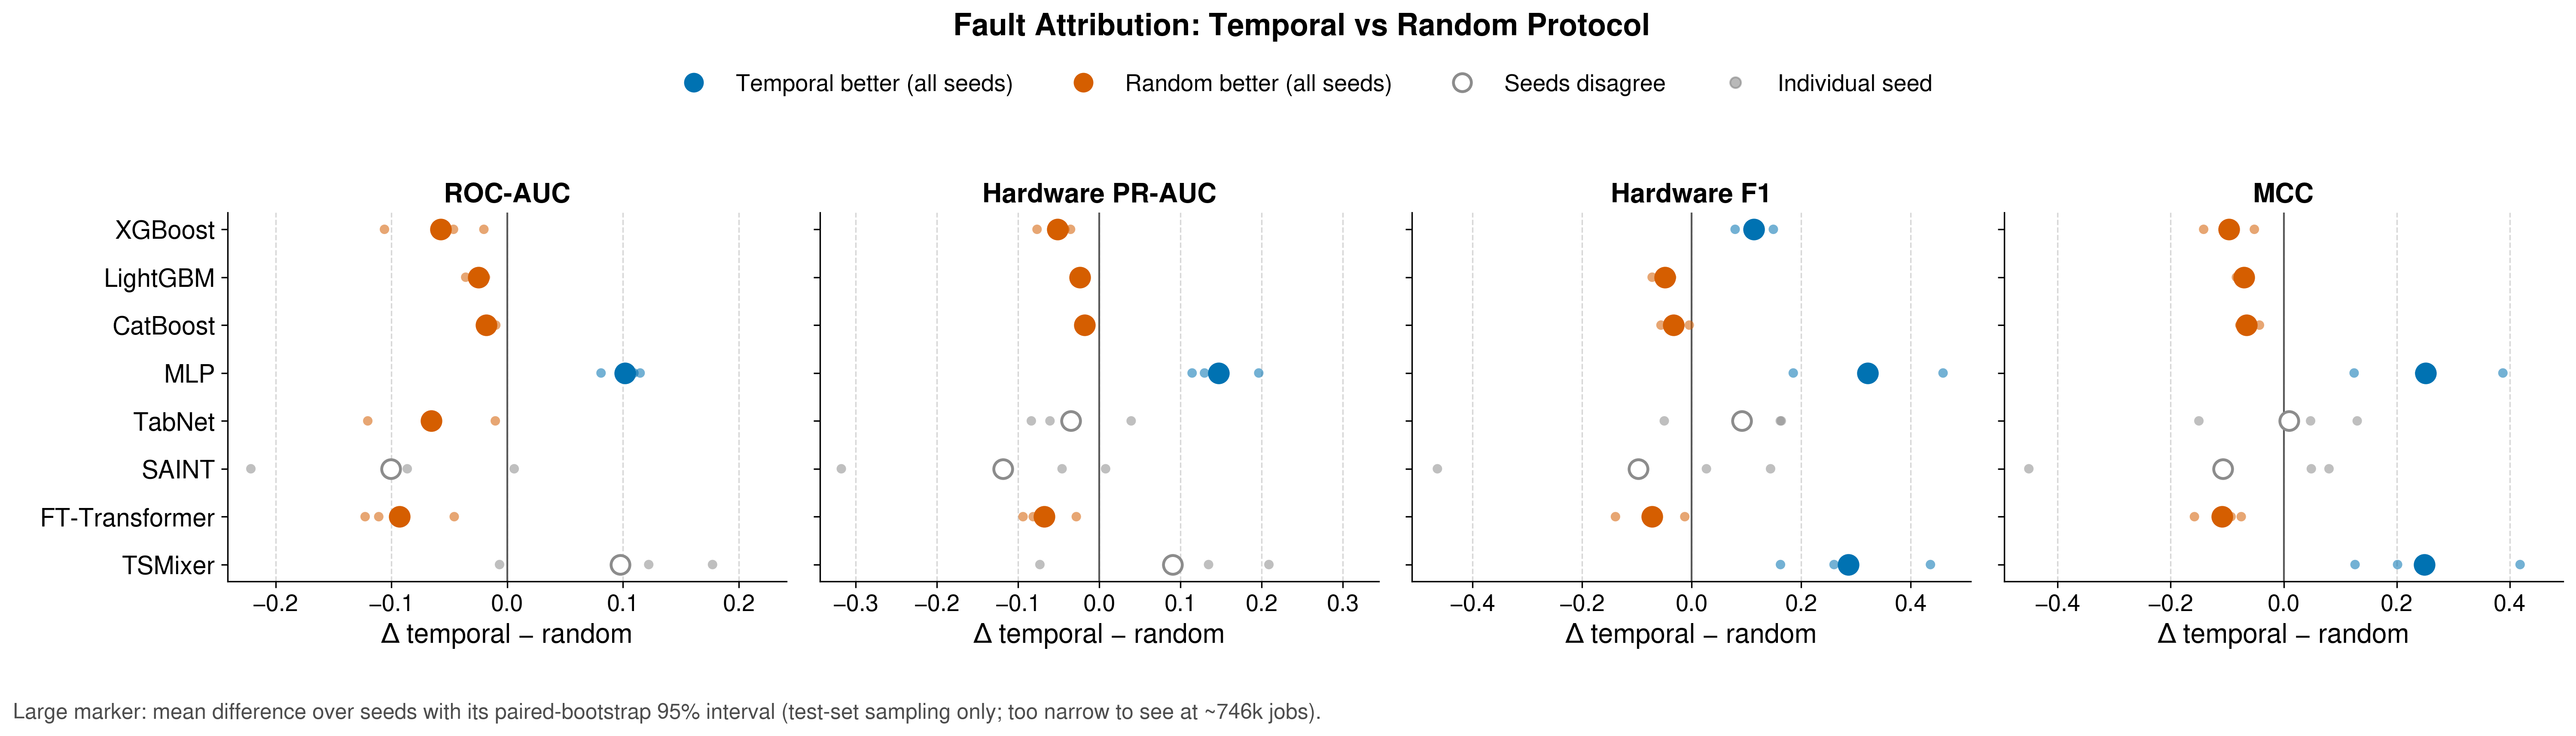

In [ ]:
# Temporal vs Random on the shared August slice: is the difference consistent?
# Each row is one model. Small dots are the three seeds' differences (temporal - random,
# both arms scored on the identical August failed jobs); the large marker is their mean
# with the paired-bootstrap 95% interval from results/oot_significance.csv
# (eval.helper.oot_protocol_significance). At ~746k test jobs that interval is
# hair-thin, so the seeds -- not the interval -- show whether a difference is real.
PANELS = [
    ("roc_auc",         "ROC-AUC"),
    ("hardware.pr_auc", "Hardware PR-AUC"),
    ("hardware.f1",     "Hardware F1"),
    ("mcc",             "MCC"),             # at the hardware threshold, as stored
]
SIG_CSV = "results/oot_significance.csv"
# ----------------------------------------------------------------------------------
import json
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

from eval.style import COLORS

MODEL_ORDER = {"xgboost": "XGBoost", "lightgbm": "LightGBM", "catboost": "CatBoost",
               "mlp": "MLP", "tabnet": "TabNet", "saint": "SAINT",
               "ft": "FT-Transformer", "tsmixer": "TSMixer"}
with open("results/fault_attr_results.json") as f:
    results = json.load(f)
sig = pd.read_csv(SIG_CSV)
model_keys = [k for k in MODEL_ORDER if k in results]


def _get(run, path):
    for p in path.split("."):
        run = run[p]
    return float(run)


def seed_deltas(mk, metric):
    """Temporal minus random, per seed, both read from each run's OOT block."""
    out = []
    for k, run in results[mk].items():
        if k.startswith("temporal__seed"):
            rk = k.replace("temporal", "random", 1)
            if rk in results[mk]:
                out.append(_get(run["oot"], metric) - _get(results[mk][rk]["oot"], metric))
    return np.array(out)


# Direction colours follow the paper's split colours; seeds that disagree are neutral.
C_TEMP, C_RAND, C_MIXED = COLORS["primary"], COLORS["secondary"], "#8C8C8C"

FONT = 14
plt.rcParams.update({
    "font.family": "sans-serif", "font.sans-serif": "Nimbus Sans",
    "font.size": FONT, "axes.labelsize": FONT + 1, "axes.titlesize": FONT + 1,
    "xtick.labelsize": FONT - 1, "ytick.labelsize": FONT,
    "legend.fontsize": FONT - 1,
})

fig, axes = plt.subplots(1, len(PANELS), figsize=(5 * len(PANELS), 5.2), sharey=True,
                         dpi=300)
y = np.arange(len(model_keys))[::-1]          # first model at the top
for ax, (metric, label) in zip(axes, PANELS):
    for yi, mk in zip(y, model_keys):
        d = seed_deltas(mk, metric)
        row = sig[(sig.model == MODEL_ORDER[mk]) & (sig.metric == metric)]
        mean = float(row["delta"].iloc[0]) if len(row) else float(d.mean())
        agree = np.all(np.sign(d) == np.sign(mean)) and mean != 0
        col = (C_TEMP if mean > 0 else C_RAND) if agree else C_MIXED
        ax.scatter(d, np.full(len(d), yi), s=28, color=col, alpha=0.55,
                   edgecolor="none", zorder=3)
        if len(row):
            ax.hlines(yi, row["ci_lo"].iloc[0], row["ci_hi"].iloc[0], color="0.2",
                      linewidth=2, zorder=4)
        ax.scatter([mean], [yi], s=110, zorder=5, linewidth=1.6,
                   facecolor=col if agree else "white", edgecolor=col)
    ax.axvline(0, color="0.35", linewidth=1, zorder=2)
    ax.set_title(label, fontweight="bold")
    ax.grid(axis="x", linestyle="--", alpha=0.5); ax.set_axisbelow(True)
    ax.spines[["top", "right"]].set_visible(False)
    lim = max(abs(v) for v in ax.get_xlim())
    ax.set_xlim(-lim, lim)                     # symmetric, so zero sits in the middle
    ax.set_xlabel("Δ temporal − random")
axes[0].set_yticks(y); axes[0].set_yticklabels([MODEL_ORDER[k] for k in model_keys])

handles = [
    Line2D([], [], marker="o", linestyle="", markersize=10, color=C_TEMP,
           label="Temporal better (all seeds)"),
    Line2D([], [], marker="o", linestyle="", markersize=10, color=C_RAND,
           label="Random better (all seeds)"),
    Line2D([], [], marker="o", linestyle="", markersize=10, markerfacecolor="white",
           markeredgecolor=C_MIXED, markeredgewidth=1.6, label="Seeds disagree"),
    Line2D([], [], marker="o", linestyle="", markersize=6, color="0.5", alpha=0.55,
           label="Individual seed"),
]
# Title, then legend, then panels: tight_layout keeps the panels below the rect top.
fig.suptitle("Fault Attribution: Temporal vs Random Protocol",
             fontweight="bold", fontsize=FONT + 3, y=0.99)
fig.legend(handles=handles, loc="upper center", ncol=4, frameon=False,
           bbox_to_anchor=(0.5, 0.93))
fig.text(0.0, -0.04,
         "Large marker: mean difference over seeds with its paired-bootstrap 95% interval "
         "(test-set sampling only; too narrow to see at ~746k jobs).",
         ha="left", va="top", fontsize=FONT - 2, color="0.30")
plt.tight_layout(rect=(0, 0, 1, 0.86))
os.makedirs("output", exist_ok=True)
plt.savefig("output/e3_oot_significance.pdf", bbox_inches="tight")
plt.show()


### E1.5: Feature Ablation on Failed task (temporal split) 
`base -> +cyclical -> +campaign type -> +trailing site/campaign/node status` 